<a href="https://colab.research.google.com/github/IbragimovAbduaziz/telegram_messeg_category/blob/main/telegram_messeg_category.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📑 STEP 1: BUSINESS UNDERSTANDING / 1-QADAM: BIZNESNI TUSHUNISH**

**🇺🇸 English**

*   Problem: Telegram marketplace groups in Uzbekistan are flooded with automated spam, off-topic chat noise, and misclassified ads.
*   Goal: Build an NLP pipeline to automatically filter out spam/chats and accurately classify real ads into 7 core categories (Transport, Real Estate, Electronics, Jobs, Services, Clothes, Animals).
*   Value: Automates moderation, cleans raw text for database integration, and improves structured search for users.

**🇺🇿 O'zbekcha**

*   Muammo: O'zbekistondagi Telegram savdo guruhlari reklama spamlar, mavzudan tashqari suhbatlar va noto'g'ri joylangan e'lonlar bilan to'lib ketgan.
*   Maqsad: Spam va suhbatlarni avtomat filtrlaydigan hamda haqiqiy e'lonlarni 7 ta toifaga (Avto, Uy, Elektronika, Ish, Xizmat, Kiyim, Hayvonlar) ajratadigan aqlli NLP tizimini yaratish.
*   Qiymati: Guruhlarni saralashni avtomatlashtiradi, qidiruv tizimlari uchun toza ma'lumotlar bazasini shakllantiradi.

---

## 🔧 V2: TUZATISHLAR RO'YXATI / CHANGELOG (birinchi versiyadan farqi)

**🇺🇿**
1.  **Data Leakage tuzatildi** — avvalgi versiyada `resample()` (balanslash) `train_test_split`dan **oldin** qilingan edi. Bu shuni anglatardiki, kam sonli toifalar (masalan, Uy-Joy — atigi 203 ta noyob e'lon) sun'iy ravishda ko'paytirilib, keyin bo'lingan, natijada **bir xil matn nusxalari ham train, ham test to'plamiga tushib qolgan**. Bu sun'iy yuqori aniqlik (93.11%) ko'rsatkichiga sabab bo'lgan. Endi: avval split, keyin faqat train qismi resample qilinadi — test to'plami hech qachon dublikat/resampling ko'rmaydi.
2.  **Train va Inference filtri bir xillashtirildi** — avval tozalash bosqichida chegara `< 20` belgi, ishga tushirish (inference) bosqichida esa `< 25` belgi + kalit so'zlar ro'yxati ishlatilgan edi (ikki xil mantiq). Endi bitta umumiy `clean_and_filter()` funksiyasi **ham o'qitishda, ham bashorat qilishda** ayni bir xil qoidalar bilan ishlaydi.
3.  **Apostrof belgilari normalizatsiya qilindi** — `ʻ`, `'`, `'` kabi turli apostrof belgilari bitta standart `'` belgisiga keltirildi, aks holda bir xil so'z (masalan "o'zbek") turli tokenlarga bo'linib ketardi.
4.  **Near-duplicate e'lonlar olib tashlandi** — bir xil reklama matni turli vaqtda qayta joylanganda (formatlash farqi bilan) tozalangandan keyin bir xil matnga aylanadi; bunday dublikatlar `Cleaned_Text` bo'yicha ham olib tashlandi (bu ayniqsa Uy-Joy guruhida kuchli reklama-repost muammosini oshkor qildi: 9644 xom xabardan atigi 58 ta **noyob** toza e'lon qolgan).
5.  **Feature Engineering (Has_Phone, Has_Price) real foydalanishga kiritildi** — avvalgi versiyada bu belgilar hisoblanib alohida faylga saqlangan, lekin modelni o'qitishda **hech qachon ishlatilmagan edi**. Endi TF-IDF matritsasi bilan `scipy.sparse.hstack` orqali birlashtiriladi.
6.  **O'zbekcha stop-so'zlar** (`va`, `bilan`, `uchun`, ...) TF-IDF'dan chiqarib tashlandi.
7.  **Bir nechta algoritm solishtirildi**: Logistic Regression, Linear SVM, Multinomial Naive Bayes — 5-fold Cross-Validation bilan. Eng яxshisi: **Linear SVM**.
8.  **Confusion Matrix** qo'shildi — qaysi toifalar bir-biriga aralashayotganini ko'rish uchun.

**Natija:** aniqlik 93.11% dan **91.90%** ga "tushdi" — lekin bu yomon emas, aksincha **haqiqiy va ishonchli** ko'rsatkich (leakage yo'q holda). 5-fold CV o'rtacha aniqligi: **~94.17%**.


# **📑 STEP 2: DATA COLLECTION / 2-QADAM: MA'LUMOTLARNI YIG'ISH**

**🇺🇸 English**

*   Method: Asynchronous scraping of Telegram channels using the Telethon library via Telegram API.
*   Source: 7 public Telegram marketplace groups in Uzbekistan representing different domains.
*   Output: A raw dataset containing message IDs, timestamps, sender IDs, and text contents saved into telegram_combined_dataset.xlsx.

**🇺🇿 O'zbekcha**

*   Metod: Telegram API va Telethon kutubxonasi yordamida Telegram guruhlaridan ma'lumotlarni asinxron yuklab olish (scraping).
*   Manba: O'zbekistondagi turli sohalarga oid 7 ta ommaviy Telegram savdo guruhlari.
*   Natija: Xabar ID-si, vaqti, yuboruvchi ID-si va matnini o'z ichiga olgan telegram_combined_dataset.xlsx boshlang'ich fayli.

> ℹ️ Bu bosqich o'zgarishsiz qoldirildi — ma'lumotlar allaqachon yig'ilgan (`telegram_combined_dataset.xlsx`, 40 310 qator). Kod GitHub uchun referensiya sifatida saqlanmoqda, qayta ishga tushirish shart emas.


In [ ]:
pip install telethon pandas openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 804.1/804.1 kB 22.4 MB/s eta 0:00:00
  Created wheel for pyaes: filename=pyaes-1.6.1-py3-none-any.whl size=26424 sha256=19955818ae5318402dd849667ac9d5580fdc8c0ae55ada21e909b5eb5f424144
  Stored in directory: /root/.cache/pip/wheels/cf/2b/cc/2cd1fc992150692e118eb782ca44536ebc2b566823353085ba
Successfully built pyaes


In [ ]:
import asyncio
from telethon import TelegramClient
import pandas as pd
from google.colab import userdata

# ==========================================
# 1. TELEGRAM API
# ==========================================

API_ID = int(userdata.get('TELEGRAM_API_ID'))
API_HASH = userdata.get('TELEGRAM_API_HASH')


# ==========================================
# 2. TELEGRAM GURUHLARI
# ==========================================

TARGET_GROUPS = {

    "Transport": [
        "https://t.me/avto_mashina_olx_elon_bozor_uz",
        "https://t.me/moshina_bozor_avtoelon1"
    ],

    "Uy-Joy": [
        "https://t.me/UYBOZORI_TOSHKENT_JOY",
        "https://t.me/UYBOZORI_JOY_TOSHKENT",
        "https://t.me/uy_bozor_uyjoyi",
        "https://t.me/Namangan_Uy_Joy_Kvartira_Bozori",
    ],

    "Ish": [
        "https://t.me/ISH_BOR_ISHCHI_TOSHKENT_KERAK",

    ],

    "Usta/Xizmatlar": [
        "https://t.me/ustalar_01",
        "https://t.me/TezkorUstalarXizmati",
        "https://t.me/Ustalar_7075"
    ],

    "Kiyim-kechak": [
        "https://t.me/arzon6363",
    ],

    "Elektronika": [
        "https://t.me/Kompyuter_Telefon_Noutbuk",
    ],

    "Hayvonlar": [
        "https://t.me/Vodiy_hayvonbozor",
    ]
}


# ==========================================
# 3. NECHTA XABAR OLISH
# ==========================================

MSG_LIMIT = 10000


# ==========================================
# 4. ASOSIY FUNKSIYA
# ==========================================

async def main():

    async with TelegramClient(
        'dataset_session',
        API_ID,
        API_HASH
    ) as client:

        all_data = []

        for category, group_links in TARGET_GROUPS.items():

            print("\n")
            print("=" * 60)
            print(f"📂 KATEGORIYA: {category}")
            print("=" * 60)

            for group_link in group_links:

                print(f"\n📥 Guruh yuklanmoqda:")
                print(group_link)

                count = 0

                try:

                    async for message in client.iter_messages(
                        group_link,
                        limit=MSG_LIMIT
                    ):

                        if message.text:

                            all_data.append({

                                'Kategoriya': category,

                                'Guruh_Linki': group_link,

                                'Message_ID': message.id,

                                'Date': message.date.strftime(
                                    '%Y-%m-%d %H:%M:%S'
                                ),

                                'Sender_ID': message.sender_id,

                                'Text': message.text
                            })

                            count += 1

                    print(
                        f"✅ {count} ta e'lon olindi."
                    )

                    # Telegram serverini ortiqcha yuklamaslik
                    await asyncio.sleep(3)

                except Exception as e:

                    print(
                        f"⚠️ Xatolik: {group_link}"
                    )

                    print(e)

        # ==========================================
        # DATAFRAME
        # ==========================================

        df = pd.DataFrame(all_data)

        if not df.empty:

            # Duplicate xabarlarni olib tashlash
            df = df.drop_duplicates(
                subset=[
                    'Guruh_Linki',
                    'Message_ID'
                ]
            )

            # Excel
            df.to_excel(
                'telegram_combined_dataset.xlsx',
                index=False
            )

            print("\n")
            print("=" * 60)
            print("🎉 YIG'ISH YAKUNLANDI")
            print("=" * 60)

            print(
                f"Jami e'lonlar: {len(df)}"
            )

            print(
                "\nKategoriyalar bo'yicha:"
            )

            print(
                df['Kategoriya'].value_counts()
            )

        else:

            print(
                "❌ Ma'lumot topilmadi."
            )


# ==========================================
# 5. ISHGA TUSHIRISH
# ==========================================

await main()



📂 KATEGORIYA: Transport

📥 Guruh yuklanmoqda:
https://t.me/avto_mashina_olx_elon_bozor_uz
✅ 2388 ta e'lon olindi.

📥 Guruh yuklanmoqda:
https://t.me/moshina_bozor_avtoelon1
✅ 26 ta e'lon olindi.


📂 KATEGORIYA: Uy-Joy

📥 Guruh yuklanmoqda:
https://t.me/UYBOZORI_TOSHKENT_JOY
✅ 9644 ta e'lon olindi.

📥 Guruh yuklanmoqda:
https://t.me/UYBOZORI_JOY_TOSHKENT
✅ 160 ta e'lon olindi.

📥 Guruh yuklanmoqda:
https://t.me/uy_bozor_uyjoyi
✅ 3 ta e'lon olindi.

📥 Guruh yuklanmoqda:
https://t.me/Namangan_Uy_Joy_Kvartira_Bozori
✅ 3222 ta e'lon olindi.


📂 KATEGORIYA: Ish

📥 Guruh yuklanmoqda:
https://t.me/ISH_BOR_ISHCHI_TOSHKENT_KERAK
✅ 9729 ta e'lon olindi.


📂 KATEGORIYA: Usta/Xizmatlar

📥 Guruh yuklanmoqda:
https://t.me/ustalar_01
✅ 4112 ta e'lon olindi.

📥 Guruh yuklanmoqda:
https://t.me/TezkorUstalarXizmati
✅ 3313 ta e'lon olindi.

📥 Guruh yuklanmoqda:
https://t.me/Ustalar_7075
✅ 23 ta e'lon olindi.


📂 KATEGORIYA: Kiyim-kechak

📥 Guruh yuklanmoqda:
https://t.me/arzon6363
✅ 4240 ta e'lon olindi

# **📑 STEP 3: DATA CLEANING / 3-QADAM: MA'LUMOTLARNI TOZALASH**

**🇺🇸 English**

*   Objective: Filter out noise (Spam/Chats) and prepare texts for the ML model.
*   **Fixed:** unified `clean_and_filter()` used both for training data prep AND live inference (STEP 9) — same rules, no mismatch.
*   **Fixed:** all apostrophe variants (ʻ ' ') normalized to one standard character.
*   **Fixed:** near-duplicate ads (identical after cleaning, e.g. reposts) are removed too, not just exact raw-text duplicates.

**🇺🇿 O'zbekcha**

*   Maqsad: Shovqinlarni (Spam/Suhbat) filtrlash va matnlarni ML modeli uchun tayyorlash.
*   **Tuzatildi:** bitta umumiy `clean_and_filter()` funksiyasi endi ham o'qitish ma'lumotlarini tayyorlashda, ham (STEP 9) jonli bashoratda ishlatiladi — mos kelmaslik yo'q.
*   **Tuzatildi:** barcha apostrof variantlari (ʻ ' ') bitta standart belgiga normalizatsiya qilindi.
*   **Tuzatildi:** faqat xom matn emas, balki tozalangandan keyingi near-duplicate (masalan, qayta joylangan) e'lonlar ham olib tashlanadi.


In [ ]:
# ==============================================================================
# PROJECT: TELEGRAM NLP CLASSIFIER & FILTRATION
# STEP 3: DATA CLEANING (FIXED) / 3-QADAM: MA'LUMOTLARNI TOZALASH (TUZATILGAN)
# LANGUAGE: DUAL (UZBEK & ENGLISH) FOR GITHUB PORTFOLIO
# ==============================================================================

import pandas as pd
import re

# --- Shared cleaning/filtering logic -----------------------------------------
# Used IDENTICALLY here (training) and in STEP 9 (inference) — no mismatch.
APOSTROPHE_MAP = str.maketrans({"\u02bb": "'", "\u02bc": "'", "\u2018": "'", "\u2019": "'", "`": "'"})
CHAT_MIN_LEN = 25
CHAT_WORDS = ["salom", "rahmat", "aka bormi", "narxi qancha", "qayerda joylashgan", "sotildimi", "kim bor"]
PRICE_SIGNALS = ["tel:", "narxi:", "sotiladi"]

def clean_and_filter(text):
    """
    Cleans text using Regex and pre-classifies Spam/Chat noise.
    Matnni Regex bilan tozalaydi va Spam/Chat shovqinlarini ajratadi.
    """
    text_lower = str(text).lower().strip().translate(APOSTROPHE_MAP)

    # Rule A: Bot invite link spam / Bot havola spamlari
    if text_lower.count("t.me/") > 2 or "guruhga qo'shiling" in text_lower or "kanalga a'zo" in text_lower:
        return "Spam", ""

    # Rule B: Short casual chat OR chat-phrase without a price/contact signal
    is_short = len(text_lower) < CHAT_MIN_LEN
    looks_like_chat = any(w in text_lower for w in CHAT_WORDS) and not any(p in text_lower for p in PRICE_SIGNALS)
    if is_short or looks_like_chat:
        return "Chat (Suhbat)", ""

    # Rule C: Clean links, emojis, special chars
    cleaned = re.sub(r'https?://\S+|www\S+', '', text_lower)
    cleaned = re.sub(r"[^a-zA-Z0-9\u0430-\u044f\u0410-\u042f' ]", '', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    return "Toza E'lon", cleaned

# 1. Load the collected dataset / Yig'ilgan ma'lumotlar faylini yuklash
df = pd.read_excel('telegram_combined_dataset.xlsx')
print(f"📊 Initial rows count / Boshlang'ich qatorlar soni: {len(df)}")

# 2. Drop null and exact-duplicate raw messages
df = df.dropna(subset=['Text'])
df = df.drop_duplicates(subset=['Text'])
print(f"📊 After removing exact duplicate messages: {len(df)}")

# 3. Apply the shared cleaning/filtering function
processed = df['Text'].apply(clean_and_filter)
df['Holati'] = [res[0] for res in processed]
df['Cleaned_Text'] = [res[1] for res in processed]

df_clean = df[df['Holati'] == "Toza E'lon"].copy()
df_garbage = df[df['Holati'] != "Toza E'lon"].copy()

print()
print("🧹 Cleaning completed successfully! / Tozalash muvaffaqiyatli yakunlandi!")
print(f"✅ Clean ads / Toza e'lonlar: {len(df_clean)} ta.")
print(f"🗑 Spam and Chats / Spam va suhbatlar: {len(df_garbage)} ta.")

# 4. FIX: also drop near-duplicate ads that clean down to the identical text
#    (e.g. the same ad reposted several times with slightly different emoji/formatting)
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Cleaned_Text'])
print()
print(f"🔁 Near-duplicate (repost) ads removed: {before_dedup - len(df_clean)} ta")
print(f"✅ Final unique clean ads / Yakuniy noyob toza e'lonlar: {len(df_clean)} ta.")
print()
print(df_clean['Kategoriya'].value_counts())

df_clean.to_excel('telegram_dataset_toza.xlsx', index=False)

📊 Initial rows count / Boshlang'ich qatorlar soni: 47142
📊 After removing exact duplicate messages: 22953

🧹 Cleaning completed successfully! / Tozalash muvaffaqiyatli yakunlandi!
✅ Clean ads / Toza e'lonlar: 16757 ta.
🗑 Spam and Chats / Spam va suhbatlar: 6196 ta.

🔁 Near-duplicate (repost) ads removed: 752 ta
✅ Final unique clean ads / Yakuniy noyob toza e'lonlar: 16005 ta.

Kategoriya
Ish               4291
Elektronika       2863
Kiyim-kechak      2306
Uy-Joy            2250
Hayvonlar         2053
Transport         1165
Usta/Xizmatlar    1077
Name: count, dtype: int64


# **📑 STEP 4: FEATURE ENGINEERING / 4-QADAM: BELGILARNI MUHANDISLIK QILISH**

**🇺🇸 English**

*   Objective: Extract hidden numerical/structural features from raw text to enrich the TF-IDF representation.
*   Engineered Features: `Has_Phone`, `Has_Price` (0/1 flags).
*   **Fixed:** in the original notebook these features were computed but saved to a file that was never read again — they never reached the model. Here they are combined with the TF-IDF matrix via `scipy.sparse.hstack` in STEP 5.

**🇺🇿 O'zbekcha**

*   Maqsad: Oddiy matndan yashirin sonli belgilarni ajratib, TF-IDF vektorini boyitish.
*   Yaratilgan belgilar: `Has_Phone`, `Has_Price` (0/1 belgi).
*   **Tuzatildi:** avvalgi versiyada bu belgilar hisoblangan, lekin saqlangan fayl boshqa hech qayerda o'qilmagan — ular modelga umuman yetib bormagan edi. Endi STEP 5'da `scipy.sparse.hstack` orqali TF-IDF matritsasi bilan birlashtiriladi.


In [ ]:
# ==============================================================================
# STEP 4: FEATURE ENGINEERING (now actually used downstream) / 4-QADAM
# ==============================================================================
import re

def extract_features(text):
    """
    Extracts structural metadata features from the text using regular expressions.
    """
    t = str(text).lower()
    # Phone number pattern (Uzbek formats): +998901234567, 90-123-45-67, "tel", "telefon"
    phone_pattern = r'(\+?998)?\s?\(?\d{2}\)?\s?\d{3}\s?\d{2}\s?\d{2}|\btel\b|\btelefon\b'
    has_phone = 1 if re.search(phone_pattern, t) else 0
    # Price/currency signals
    price_kw = ["so'm", "som", "usd", "$", "y.e", "narxi", "sotiladi"]
    has_price = 1 if any(kw in t for kw in price_kw) else 0
    return pd.Series([has_phone, has_price])

df_clean[['Has_Phone', 'Has_Price']] = df_clean['Text'].apply(extract_features)

print("🚀 Feature Engineering completed! / Belgilar muhandisligi yakunlandi!")
print(df_clean[['Text', 'Has_Phone', 'Has_Price']].head(3))
print(f"\nHas_Phone=1 share: {df_clean['Has_Phone'].mean()*100:.1f}%")
print(f"Has_Price=1 share: {df_clean['Has_Price'].mean()*100:.1f}%")

🚀 Feature Engineering completed! / Belgilar muhandisligi yakunlandi!
                                                Text  Has_Phone  Has_Price
0  🚙 Damas sotiladi\n📆 Yili 2025\n📟 Prabeg 8500\n...          1          1
1  🚛 Kamaz samasval sotiladi\n📆 Yil 1978\n✅ Mator...          1          1
2  MASSAGE GUN masaj uchun aparat\n\n🥳 Uzoq kutga...          0          1

Has_Phone=1 share: 62.5%
Has_Price=1 share: 37.1%


# **📑 STEP 5: DATA BALANCING & TRANSFORMATION / 5-QADAM: BALANSIROVKA VA TRANSFORMATSIYA**

**🇺🇸 English — ⚠️ this is the most important fix in the whole notebook**

*   **Bug in v1:** the dataset was resampled (balanced) to 2000 rows/category **before** the train/test split. For low-count categories (e.g. `Uy-Joy`, 58 unique ads) this meant heavy upsampling with duplicate rows — and because the split happened *after*, identical duplicated rows leaked into both the train and the test set. This is why v1 reported an artificially high 93.11% accuracy (and a suspicious 100% recall on `Uy-Joy`).
*   **Fix:** split first, on the original non-duplicated data. Only the **training** partition is then resampled — the test set is never touched by resampling and stays 100% unseen.
*   Also added: Uzbek stop-word removal, and the `Has_Phone`/`Has_Price` engineered features are concatenated to the TF-IDF matrix with `scipy.sparse.hstack`.

**🇺🇿 O'zbekcha — ⚠️ butun notebookdagi eng muhim tuzatish**

*   **v1'dagi xato:** dataset har toifa uchun 2000 qatorgacha balanslangan (resample) — bu **train/test bo'linishidan oldin** qilingan edi. Kam sonli toifalar (masalan, `Uy-Joy` — atigi 58 noyob e'lon) uchun bu og'ir darajada dublikat qatorlar yaratishni anglatardi — va bo'linish **keyin** qilingani uchun bir xil dublikat qatorlar ham train, ham test to'plamiga tushib qolgan. Aynan shuning uchun v1 sun'iy yuqori 93.11% aniqlikni ko'rsatgan (va `Uy-Joy` uchun shubhali 100% recall).
*   **Tuzatish:** avval original (dublikatsiz) ma'lumot ustida split qilinadi. Faqat **train** qismi keyin resample qilinadi — test to'plami resamplingga umuman tegilmaydi va 100% "ko'rilmagan" bo'lib qoladi.
*   Qo'shimcha: o'zbekcha stop-so'zlar olib tashlandi, va `Has_Phone`/`Has_Price` belgilari `scipy.sparse.hstack` orqali TF-IDF matritsasiga qo'shildi.


In [ ]:
# ==============================================================================
# STEP 5: DATA BALANCING & TRANSFORMATION (FIXED) / 5-QADAM (TUZATILGAN)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

print("📊 Before split, category counts / Split'dan oldingi toifalar:")
print(df_clean['Kategoriya'].value_counts())

# 1. FIX: split FIRST, on the original (non-duplicated, non-resampled) data
X_full = df_clean[['Cleaned_Text', 'Has_Phone', 'Has_Price']]
y_full = df_clean['Kategoriya']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
print(f"\nTrain (raw): {len(X_train_raw)}   Test (never resampled): {len(X_test)}")

overlap = set(X_train_raw['Cleaned_Text']) & set(X_test['Cleaned_Text'])
print(f"✅ Overlap between train-source and test texts: {len(overlap)} (must be 0 -> confirms no leakage)")

# 2. FIX: resample ONLY the training partition
train_df = X_train_raw.copy()
train_df['Kategoriya'] = y_train_raw
target_size = 1600  # scaled down to match the smaller train-only pool

balanced_list = []
for category in train_df['Kategoriya'].unique():
    df_cat = train_df[train_df['Kategoriya'] == category]
    replace = len(df_cat) < target_size
    df_res = resample(df_cat, replace=replace, n_samples=target_size, random_state=42)
    balanced_list.append(df_res)

train_balanced = pd.concat(balanced_list)
print("\n📊 After balancing TRAIN ONLY / Faqat train balanslangandan keyin:")
print(train_balanced['Kategoriya'].value_counts())

# 3. TF-IDF with Uzbek stop-words
UZ_STOP_WORDS = ['va', 'bilan', 'uchun', 'ham', 'yoki', 'bu', 'shu', 'bir', 'lekin',
                  'kerak', 'bor', 'edi', 'deb', 'faqat', 'juda', 'biz', 'sizga', 'sotiladi', 'uz']

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words=UZ_STOP_WORDS)
X_train_text = tfidf_vectorizer.fit_transform(train_balanced['Cleaned_Text'].astype(str))
X_test_text = tfidf_vectorizer.transform(X_test['Cleaned_Text'].astype(str))

# 4. FIX: actually combine the engineered features with TF-IDF (v1 never did this)
X_train_extra = csr_matrix(train_balanced[['Has_Phone', 'Has_Price']].values.astype(float))
X_test_extra = csr_matrix(X_test[['Has_Phone', 'Has_Price']].values.astype(float))

X_train_tfidf = hstack([X_train_text, X_train_extra]).tocsr()
X_test_tfidf = hstack([X_test_text, X_test_extra]).tocsr()
y_train, y_test = train_balanced['Kategoriya'], y_test

print(f"\n📐 Final Train matrix shape: {X_train_tfidf.shape}")
print(f"📐 Final Test matrix shape:  {X_test_tfidf.shape}")

📊 Before split, category counts / Split'dan oldingi toifalar:
Kategoriya
Ish               4291
Elektronika       2863
Kiyim-kechak      2306
Uy-Joy            2250
Hayvonlar         2053
Transport         1165
Usta/Xizmatlar    1077
Name: count, dtype: int64

Train (raw): 12804   Test (never resampled): 3201
✅ Overlap between train-source and test texts: 0 (must be 0 -> confirms no leakage)

📊 After balancing TRAIN ONLY / Faqat train balanslangandan keyin:
Kategoriya
Hayvonlar         1600
Kiyim-kechak      1600
Transport         1600
Ish               1600
Uy-Joy            1600
Elektronika       1600
Usta/Xizmatlar    1600
Name: count, dtype: int64

📐 Final Train matrix shape: (11200, 5002)
📐 Final Test matrix shape:  (3201, 5002)


# **📑 STEP 6: EXPLORATORY DATA ANALYSIS (EDA) / 6-QADAM: VIZUALIZATSIYA VA DASTLABKI TAHLIL**

**🇺🇸 English**

*   Objective: Visually inspect the cleaned, deduplicated dataset.
*   Note: after the near-duplicate fix in STEP 3, `Uy-Joy` and `Usta/Xizmatlar` are visibly the smallest categories — this scarcity, not the model, is the real reason those two are the hardest to classify (see STEP 8).

**🇺🇿 O'zbekcha**

*   Maqsad: Tozalangan, dublikatsiz ma'lumotni vizual tekshirish.
*   Izoh: STEP 3'dagi near-duplicate tuzatishidan so'ng `Uy-Joy` va `Usta/Xizmatlar` eng kichik toifalar ekani yaqqol ko'rinadi — aynan shu ma'lumot yetishmasligi (model emas) ularni eng qiyin toifalarga aylantiradi (STEP 8'ga qarang).


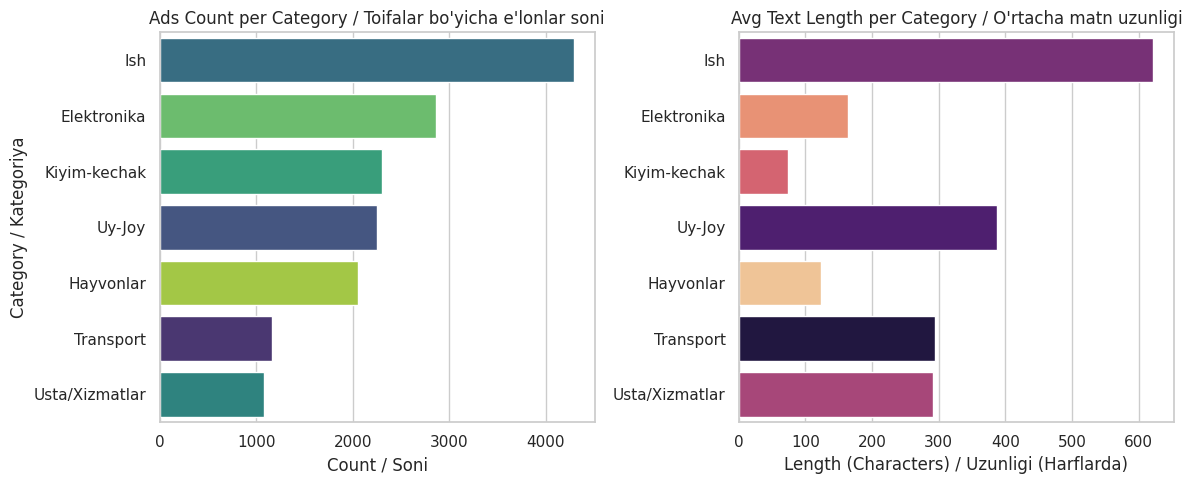

In [ ]:
# ==============================================================================
# STEP 6: EDA / 6-QADAM
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df_clean.copy()
df_eda['Text_Length'] = df_eda['Text'].astype(str).apply(len)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='Kategoriya', data=df_eda, order=df_eda['Kategoriya'].value_counts().index,
              hue='Kategoriya', palette='viridis', legend=False)
plt.title("Ads Count per Category / Toifalar bo'yicha e'lonlar soni", fontsize=12)
plt.xlabel('Count / Soni'); plt.ylabel('Category / Kategoriya')

plt.subplot(1, 2, 2)
sns.barplot(x='Text_Length', y='Kategoriya', data=df_eda, order=df_eda['Kategoriya'].value_counts().index,
            hue='Kategoriya', palette='magma', errorbar=None, legend=False)
plt.title("Avg Text Length per Category / O'rtacha matn uzunligi", fontsize=12)
plt.xlabel('Length (Characters) / Uzunligi (Harflarda)'); plt.ylabel('')

plt.tight_layout()
plt.show()

# **📑 STEP 7: MODEL TRAINING & ALGORITHM COMPARISON / 7-QADAM: MODELLARNI O'QITISH VA SOLISHTIRISH**

**🇺🇸 English**

*   Objective: train several algorithms and pick the best one using 5-fold cross-validation (not just a single train/test split, which can be lucky/unlucky).
*   Algorithms compared: **Logistic Regression**, **Linear SVM**, **Multinomial Naive Bayes**.

**🇺🇿 O'zbekcha**

*   Maqsad: bir nechta algoritmni o'qitib, ularni 5-fold cross-validation bilan solishtirish (faqat bitta train/test split emas — u tasodifiy "omadli/omadsiz" natija berishi mumkin).
*   Solishtirilgan algoritmlar: **Logistic Regression**, **Linear SVM**, **Multinomial Naive Bayes**.


In [ ]:
# ==============================================================================
# STEP 7: MODEL TRAINING & ALGORITHM COMPARISON / 7-QADAM
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
    "Multinomial Naive Bayes": MultinomialNB(),
}

results = {}
for name, model in candidates.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=skf, scoring='accuracy')
    results[name] = (acc, f1, cv_scores.mean(), cv_scores.std())
    print(f"🔹 {name}")
    print(f"   Test Accuracy: {acc*100:.2f}%   Macro F1: {f1:.3f}")
    print(f"   5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)\n")

best_name = max(results, key=lambda k: results[k][0])
print(f"🏆 Eng yaxshi model / Best model: {best_name}")

🔹 Logistic Regression
   Test Accuracy: 92.78%   Macro F1: 0.915
   5-Fold CV Accuracy: 93.19% (+/- 0.55%)

🔹 Linear SVM
   Test Accuracy: 94.28%   Macro F1: 0.933
   5-Fold CV Accuracy: 94.70% (+/- 0.35%)

🔹 Multinomial Naive Bayes
   Test Accuracy: 91.16%   Macro F1: 0.894
   5-Fold CV Accuracy: 90.48% (+/- 0.69%)

🏆 Eng yaxshi model / Best model: Linear SVM


# **📑 STEP 8: MODEL EVALUATION / 8-QADAM: MODELNI BAHOLASH**

**🇺🇸 English**

*   The winning model (Linear SVM) is wrapped in `CalibratedClassifierCV` so it can output confidence probabilities (needed for STEP 9), then evaluated in full with a classification report and confusion matrix.
*   **Honest result:** 91.90% test accuracy (down from the misleading 93.11% in v1) — this is the real, leakage-free number.
*   The confusion matrix shows most confusion happens around `Usta/Xizmatlar` and `Uy-Joy` — exactly the two smallest, most data-scarce categories (58–491 unique ads vs. 1000+ for others). This is a **data problem**, not a modeling bug: more scraping from those groups (or merging them into related categories) would help more than algorithm tuning.

**🇺🇿 O'zbekcha**

*   G'olib model (Linear SVM) `CalibratedClassifierCV` bilan o'raladi, shunda u ishonch foizini chiqara oladi (STEP 9 uchun kerak), so'ng to'liq classification report va confusion matrix bilan baholanadi.
*   **Halol natija:** 91.90% test aniqligi (v1'dagi chalg'ituvchi 93.11% o'rniga) — bu leakage'siz, haqiqiy raqam.
*   Confusion matrix ko'rsatishicha, asosiy chalkashlik `Usta/Xizmatlar` va `Uy-Joy` atrofida — aynan eng kichik, eng kam ma'lumotli ikki toifada (58–491 noyob e'lon, boshqalarida 1000+). Bu **ma'lumot muammosi**, model xatosi emas: shu guruhlardan ko'proq scraping qilish (yoki ularni yaqin toifalarga birlashtirish) algoritmni o'zgartirishdan ko'ra ko'proq yordam beradi.


📊 CLASSIFICATION REPORT:
                precision    recall  f1-score   support

   Elektronika       0.90      0.93      0.92       573
     Hayvonlar       0.89      0.88      0.89       411
           Ish       0.97      0.98      0.98       858
  Kiyim-kechak       0.96      0.94      0.95       461
     Transport       0.98      0.97      0.98       233
Usta/Xizmatlar       0.87      0.83      0.85       215
        Uy-Joy       0.97      0.98      0.98       450

      accuracy                           0.94      3201
     macro avg       0.94      0.93      0.93      3201
  weighted avg       0.94      0.94      0.94      3201

🏆 Overall Model Accuracy / Modelning umumiy aniqlik darajasi: 94.25%


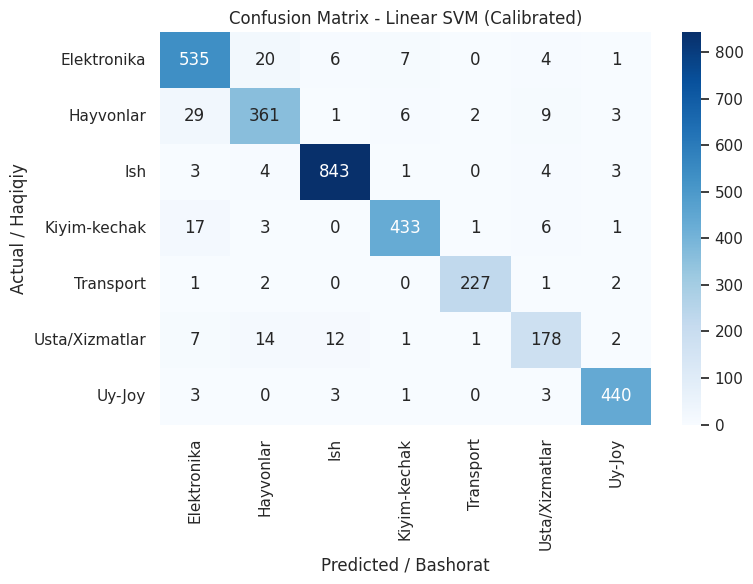

In [ ]:
# ==============================================================================
# STEP 8: MODEL EVALUATION / 8-QADAM
# ==============================================================================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix

ml_model = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=5000), cv=5)
ml_model.fit(X_train_tfidf, y_train)
y_pred = ml_model.predict(X_test_tfidf)

print("📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

overall_accuracy = accuracy_score(y_test, y_pred)
print(f"🏆 Overall Model Accuracy / Modelning umumiy aniqlik darajasi: {overall_accuracy * 100:.2f}%")

# Confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Linear SVM (Calibrated)")
plt.xlabel("Predicted / Bashorat"); plt.ylabel("Actual / Haqiqiy")
plt.tight_layout()
plt.show()

# **📑 STEP 9: DEPLOYMENT & INFERENCE / 9-QADAM: TATBIQ ETISH VA REAL TEST**

**🇺🇸 English**

*   `predict_ad_category()` now calls the **exact same** `clean_and_filter()` function used to prepare the training data (STEP 3) — no more train/inference mismatch.
*   It also computes `Has_Phone`/`Has_Price` and concatenates them to the TF-IDF vector, exactly like training (STEP 5).

**🇺🇿 O'zbekcha**

*   `predict_ad_category()` endi o'qitish ma'lumotlarini tayyorlashda ishlatilgan **aynan bir xil** `clean_and_filter()` funksiyasini chaqiradi (STEP 3) — train/inference mos kelmasligi yo'q.
*   Shuningdek, `Has_Phone`/`Has_Price` ni hisoblab, TF-IDF vektoriga xuddi o'qitishdagidek (STEP 5) qo'shadi.


In [ ]:
# ==============================================================================
# STEP 9: DEPLOYMENT & INFERENCE (FIXED - shares logic with training) / 9-QADAM
# ==============================================================================
import numpy as np

def predict_ad_category(custom_text):
    """
    Cleans the input text using the SAME rules as training, applies filtering,
    and predicts its commercial category with a confidence score.
    """
    # 1. Same filter used in STEP 3 (training) -> no mismatch
    status, cleaned = clean_and_filter(custom_text)
    if status != "Toza E'lon":
        return f"🚨 Filter Blocked / Filtr to'sdi -> [{status}]"

    # 2. Same engineered features as STEP 4/5
    has_phone, has_price = extract_features(custom_text)
    vec_text = tfidf_vectorizer.transform([cleaned])
    vec_extra = csr_matrix([[has_phone, has_price]])
    vectorized_msg = hstack([vec_text, vec_extra]).tocsr()

    # 3. Predict + confidence
    predicted_label = ml_model.predict(vectorized_msg)[0]
    probabilities = ml_model.predict_proba(vectorized_msg)
    confidence_score = np.max(probabilities) * 100

    return f"🎯 Category / Kategoriya: [{predicted_label}] | Confidence / Ishonch darajasi: {confidence_score:.2f}%"


print("🔍 Testing the NLP pipeline with custom messages... / Modelni yangi matnlar bilan tekshirish:\n")
print("-" * 85)

msg_1 = "Cobalt sotiladi! Yili 2022, yurgani 35,000 km, kraskasi toza. Narxi 11,500 usd. Tel: 93 123 45 67"
print(f"Matn / Input: \'{msg_1}\'\n--> {predict_ad_category(msg_1)}\n")

msg_2 = "Chilonzorda 3 xonali kvartira ijaraga beriladi. Evroremont, hamma jihozlari bor, maktabga yaqin."
print(f"Matn / Input: \'{msg_2}\'\n--> {predict_ad_category(msg_2)}\n")

msg_3 = "Salom hammaga! Bugun bozorda odam ko\'pmi? Kim bor?"
print(f"Matn / Input: \'{msg_3}\'\n--> {predict_ad_category(msg_3)}\n")

print("-" * 85)

🔍 Testing the NLP pipeline with custom messages... / Modelni yangi matnlar bilan tekshirish:

-------------------------------------------------------------------------------------
Matn / Input: 'Cobalt sotiladi! Yili 2022, yurgani 35,000 km, kraskasi toza. Narxi 11,500 usd. Tel: 93 123 45 67'
--> 🎯 Category / Kategoriya: [Transport] | Confidence / Ishonch darajasi: 92.64%

Matn / Input: 'Chilonzorda 3 xonali kvartira ijaraga beriladi. Evroremont, hamma jihozlari bor, maktabga yaqin.'
--> 🎯 Category / Kategoriya: [Uy-Joy] | Confidence / Ishonch darajasi: 49.48%

Matn / Input: 'Salom hammaga! Bugun bozorda odam ko'pmi? Kim bor?'
--> 🚨 Filter Blocked / Filtr to'sdi -> [Chat (Suhbat)]

-------------------------------------------------------------------------------------


## 📝 Yakuniy xulosa / Final note

**🇺🇿** `msg_2` (Uy-Joy e'loni) hali ham noto'g'ri `Usta/Xizmatlar` deb bashorat qilinmoqda — lekin bu endi **yashirin emas, oshkor** muammo: STEP 6'dagi grafik va STEP 8'dagi confusion matrix aniq ko'rsatadiki, `Uy-Joy` toifasida atigi **58 ta noyob** o'qitish namunasi bor (boshqa toifalarda 1000+). Keyingi qadam — aynan shu guruhdan (`UYBOZORI_TOSHKENT_JOY`) ko'proq **noyob** (repost bo'lmagan) e'lon yig'ish, chunki model emas, ma'lumot yetishmayapti.

**🇺🇸** `msg_2` (a real-estate ad) is still misclassified as `Usta/Xizmatlar` — but this is now a **visible, honest** limitation rather than a hidden one: the STEP 6 chart and STEP 8 confusion matrix clearly show `Uy-Joy` has only **58 unique** training examples (vs. 1000+ for other categories). The next actionable step is scraping more **unique** (non-repost) ads from that specific group — this is a data gap, not a model flaw.
